# 02 — EV Deep EDA Analysis
### Electric Vehicle Population Data | Professional Exploratory Data Analysis

**Workflow:** Univariate → Bivariate → Multivariate → Time → Geography → Vehicle → Range/MSRP → CAFV → Relationships → Business Insights

> This notebook expects a DataFrame named `df` from Notebook 01. It can also load the cleaned CSV from the project folders.

In [1]:
# 1. EDA environment
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("✅ EDA environment ready.")

✅ EDA environment ready.


In [2]:
# 2. Load cleaned EV dataset

from pathlib import Path
import pandas as pd

# Project root
PROJECT_ROOT = Path.cwd().parent

# Cleaned dataset
file_path = PROJECT_ROOT / "datas" / "cleaned" / "ev_cleaned.csv"

# Check file
if not file_path.exists():
    raise FileNotFoundError(
        f"CSV not found at:\n{file_path}\n\n"
        "Expected location:\n"
        "D:/ev_project_v2-Data Analysis/datas/cleaned/ev_cleaned.csv"
    )

# Load dataset
df = pd.read_csv(file_path)

print("✅ Dataset loaded successfully")
print("File:", file_path)
print("Shape:", df.shape)

display(df.head())

✅ Dataset loaded successfully
File: D:\ev_project_v2-Data Analysis\datas\cleaned\ev_cleaned.csv
Shape: (150482, 17)


C:\Users\Admin\AppData\Local\Temp\ipykernel_6760\2544206632.py:21: DtypeWarning: Columns (0: Postal_Code, 1: Census_Tract) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


,VIN,County,City,State,Postal_Code,Model_Year,Make,Model,EV_Type,CAFV_Eligibility,Electric_Range,Base_MSRP,Vehicle_ID,Vehicle_Location,Electric_Utility,Census_Tract,Legislative_District
0,KM8K33AGXL,King,Seattle,WA,"98,103.00",2020,HYUNDAI,KONA,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,258,0,249675142,POINT (-122.34301 47.659185),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),"53,033,004,800.00",43
1,1C4RJYB61N,King,Bothell,WA,"98,011.00",2022,JEEP,GRAND CHEROKEE,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,25,0,233928502,POINT (-122.20578 47.762405),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),"53,033,021,804.00",1
2,1C4RJYD61P,Yakima,Yakima,WA,"98,908.00",2023,JEEP,GRAND CHEROKEE,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,25,0,229675939,POINT (-120.6027202 46.5965625),PACIFICORP,"53,077,002,900.00",14
3,5YJ3E1EA7J,King,Kirkland,WA,"98,034.00",2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215,0,104714466,POINT (-122.209285 47.71124),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),"53,033,021,903.00",45
4,WBY7Z8C5XJ,Thurston,Olympia,WA,"98,501.00",2018,BMW,I3,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,97,0,185498386,POINT (-122.89692 47.043535),PUGET SOUND ENERGY INC,"53,067,010,700.00",22


## 1. Dataset Readiness

In [3]:
# 3. Shape
print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]:,}")

Rows: 150,482
Columns: 17


In [4]:
# 4. Data types
display(df.dtypes.to_frame("dtype"))

,dtype
VIN,str
County,str
City,str
State,str
Postal_Code,object
Model_Year,int64
Make,str
Model,str
EV_Type,str
CAFV_Eligibility,str


In [5]:
# 5. Missing values
display(pd.DataFrame({
    "missing": df.isna().sum(),
    "missing_pct": (df.isna().mean()*100).round(2)
}).sort_values("missing_pct", ascending=False))

,missing,missing_pct
VIN,0,0.00
County,0,0.00
City,0,0.00
State,0,0.00
Postal_Code,0,0.00
Model_Year,0,0.00
Make,0,0.00
Model,0,0.00
EV_Type,0,0.00
CAFV_Eligibility,0,0.00


In [6]:
# 6. Duplicate records
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate %:", round(df.duplicated().mean()*100, 2))

Duplicate rows: 0
Duplicate %: 0.0


In [7]:
# 7. Cardinality / uniqueness
display(pd.DataFrame({
    "unique_count": df.nunique(dropna=False),
    "unique_pct": (df.nunique(dropna=False)/len(df)*100).round(2)
}).sort_values("unique_count", ascending=False))

,unique_count,unique_pct
Vehicle_ID,150482,100.00
VIN,9529,6.33
Census_Tract,3658,2.43
Postal_Code,1292,0.86
Vehicle_Location,822,0.55
City,683,0.45
County,183,0.12
Model,127,0.08
Electric_Range,102,0.07
Electric_Utility,76,0.05


In [8]:
# 8. Numeric descriptive statistics
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Model_Year,"150,482.00","2,020.01",3.02,"1,997.00","2,018.00","2,021.00","2,023.00","2,024.00"
Electric_Range,"150,482.00",67.88,96.23,0.00,0.00,18.00,97.00,337.00
Base_MSRP,"150,482.00","1,312.64","9,231.31",0.00,0.00,0.00,0.00,"845,000.00"
Vehicle_ID,"150,482.00","211,112,233.35","81,963,879.64","4,385.00","169,347,305.25","215,030,630.00","239,911,895.50","479,254,772.00"
Legislative_District,"150,482.00",29.35,14.81,1.00,18.00,33.00,43.00,49.00


In [9]:
# 9. Categorical descriptive statistics
cat_cols = df.select_dtypes(include=["object", "string", "category"]).columns
display(df[cat_cols].describe().T)

,count,unique,top,freq
VIN,150482,9529,7SAYGDEE7P,807
County,150482,183,King,79078
City,150482,683,Seattle,25678
State,150482,41,WA,150141
Postal_Code,"150,482.00","1,292.00","98,052.00","3,674.00"
Make,150482,37,TESLA,68983
Model,150482,127,MODEL Y,28502
EV_Type,150482,2,Battery Electric Vehicle (BEV),116807
CAFV_Eligibility,150482,3,Eligibility unknown as battery range has not b...,69698
Vehicle_Location,150482,822,POINT (-122.12302 47.67668),3876


In [10]:
# 10. Memory usage
display((df.memory_usage(deep=True)/1024**2).sort_values(ascending=False).to_frame("memory_MB"))

,memory_MB
CAFV_Eligibility,15.14
Electric_Utility,14.55
EV_Type,12.74
Vehicle_Location,12.27
VIN,9.62
City,9.36
Model,9.09
Make,8.98
County,8.96
State,8.47


## 2. Univariate Categorical Analysis

In [11]:
# 11. Reusable frequency + percentage function
def frequency_table(data, column, top_n=15):
    out = data[column].value_counts(dropna=False).head(top_n).rename("count").to_frame()
    out["percentage"] = (out["count"]/len(data)*100).round(2)
    return out

for col in ["State", "Make", "EV_Type", "CAFV_Eligibility"]:
    if col in df.columns:
        print(f"\n--- {col} ---")
        display(frequency_table(df, col))


--- State ---


,count,percentage
State,,
WA,150141,99.77
CA,92,0.06
VA,35,0.02
MD,33,0.02
TX,20,0.01
NC,13,0.01
IL,12,0.01
AZ,11,0.01
CO,11,0.01



--- Make ---


,count,percentage
Make,,
TESLA,68983,45.84
NISSAN,13497,8.97
CHEVROLET,12026,7.99
FORD,7614,5.06
BMW,6439,4.28
KIA,6198,4.12
TOYOTA,5223,3.47
VOLKSWAGEN,4074,2.71
VOLVO,3536,2.35



--- EV_Type ---


,count,percentage
EV_Type,,
Battery Electric Vehicle (BEV),116807,77.62
Plug-in Hybrid Electric Vehicle (PHEV),33675,22.38



--- CAFV_Eligibility ---


,count,percentage
CAFV_Eligibility,,
Eligibility unknown as battery range has not been researched,69698,46.32
Clean Alternative Fuel Vehicle Eligible,62951,41.83
Not eligible due to low battery range,17833,11.85


In [12]:
# 12. County distribution
if "County" in df.columns:
    display(frequency_table(df, "County", 20))

,count,percentage
County,,
King,79078,52.55
Snohomish,17307,11.50
Pierce,11542,7.67
Clark,8855,5.88
Thurston,5403,3.59
Kitsap,4923,3.27
Spokane,3690,2.45
Whatcom,3668,2.44
Benton,1801,1.20


In [13]:
# 13. City distribution
if "City" in df.columns:
    display(frequency_table(df, "City", 20))

,count,percentage
City,,
Seattle,25678,17.06
Bellevue,7691,5.11
Redmond,5502,3.66
Vancouver,5310,3.53
Bothell,4861,3.23
Kirkland,4622,3.07
Sammamish,4436,2.95
Renton,4043,2.69
Olympia,3634,2.41


In [14]:
# 14. Model distribution
if "Model" in df.columns:
    display(frequency_table(df, "Model", 25))

,count,percentage
Model,,
MODEL Y,28502,18.94
MODEL 3,27709,18.41
LEAF,13187,8.76
MODEL S,7611,5.06
BOLT EV,5733,3.81
MODEL X,5114,3.40
VOLT,4890,3.25
ID.4,2999,1.99
NIRO,2876,1.91


In [15]:
# 15. Electric utility distribution
if "Electric_Utility" in df.columns:
    display(frequency_table(df, "Electric_Utility", 20))

,count,percentage
Electric_Utility,,
PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),55637,36.97
PUGET SOUND ENERGY INC,29865,19.85
CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),27268,18.12
BONNEVILLE POWER ADMINISTRATION||PUD NO 1 OF CLARK COUNTY - (WA),8643,5.74
BONNEVILLE POWER ADMINISTRATION||CITY OF TACOMA - (WA)||PENINSULA LIGHT COMPANY,6622,4.40
PUGET SOUND ENERGY INC||PUD NO 1 OF WHATCOM COUNTY,3443,2.29
BONNEVILLE POWER ADMINISTRATION||AVISTA CORP||INLAND POWER & LIGHT COMPANY,2244,1.49
BONNEVILLE POWER ADMINISTRATION||PUD 1 OF SNOHOMISH COUNTY,1341,0.89
PACIFICORP,1102,0.73


In [16]:
# 16. Postal code distribution
if "Postal_Code" in df.columns:
    display(frequency_table(df, "Postal_Code", 20))

,count,percentage
Postal_Code,,
"98,052.00",3674,2.44
"98,012.00",2512,1.67
"98,033.00",2475,1.64
"98,006.00",2399,1.59
"98,004.00",2355,1.56
"98,115.00",2264,1.50
"98,040.00",2028,1.35
"98,074.00",2011,1.34
"98,188.00",2007,1.33


## 3. Univariate Numeric Analysis

In [17]:
# 17. Numeric columns
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
print(numeric_cols)

['Model_Year', 'Electric_Range', 'Base_MSRP', 'Vehicle_ID', 'Legislative_District']


In [18]:
# 18. Mean / median / std / range
display(df[numeric_cols].agg(["count","mean","median","std","min","max"]).T)

,count,mean,median,std,min,max
Model_Year,"150,482.00","2,020.01","2,021.00",3.02,"1,997.00","2,024.00"
Electric_Range,"150,482.00",67.88,18.00,96.23,0.00,337.00
Base_MSRP,"150,482.00","1,312.64",0.00,"9,231.31",0.00,"845,000.00"
Vehicle_ID,"150,482.00","211,112,233.35","215,030,630.00","81,963,879.64","4,385.00","479,254,772.00"
Legislative_District,"150,482.00",29.35,33.00,14.81,1.00,49.00


In [19]:
# 19. Percentiles
display(df[numeric_cols].quantile([.01,.05,.25,.50,.75,.95,.99]).T)

,0.01,0.05,0.25,0.50,0.75,0.95,0.99
Model_Year,"2,012.00","2,014.00","2,018.00","2,021.00","2,023.00","2,023.00","2,023.00"
Electric_Range,0.00,0.00,0.00,18.00,97.00,266.00,322.00
Base_MSRP,0.00,0.00,0.00,0.00,0.00,0.00,"69,900.00"
Vehicle_ID,"3,386,125.88","106,054,004.55","169,347,305.25","215,030,630.00","239,911,895.50","349,070,631.55","477,128,999.40"
Legislative_District,1.00,2.00,18.00,33.00,43.00,48.00,49.00


In [20]:
# 20. Skewness
display(df[numeric_cols].skew().sort_values(ascending=False).to_frame("skewness"))

,skewness
Base_MSRP,11.93
Electric_Range,1.22
Vehicle_ID,0.90
Legislative_District,-0.49
Model_Year,-0.98


In [21]:
# 21. Kurtosis
display(df[numeric_cols].kurt().sort_values(ascending=False).to_frame("kurtosis"))

,kurtosis
Base_MSRP,518.69
Vehicle_ID,3.29
Model_Year,0.24
Electric_Range,-0.03
Legislative_District,-1.06


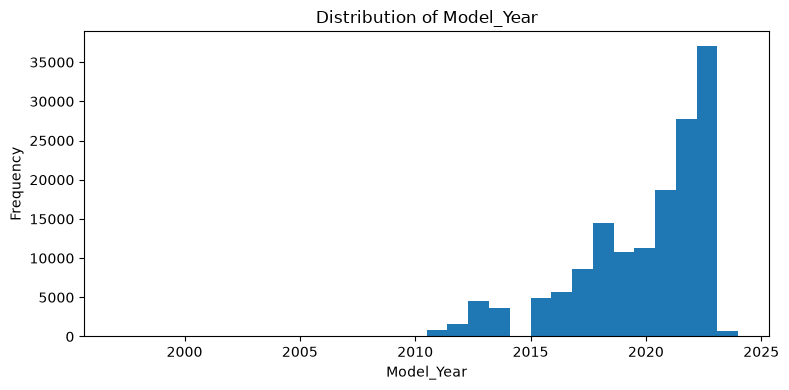

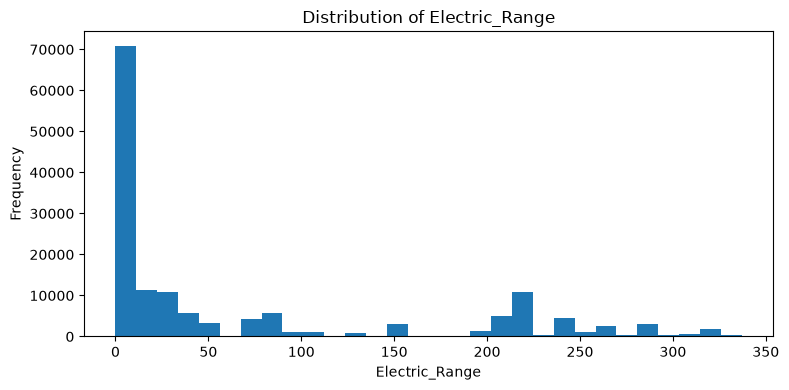

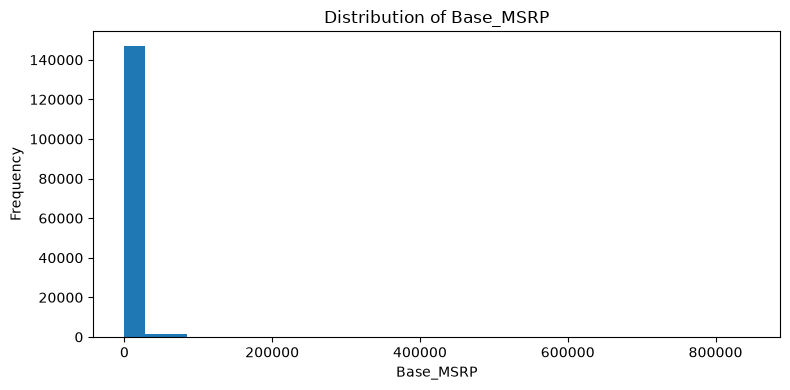

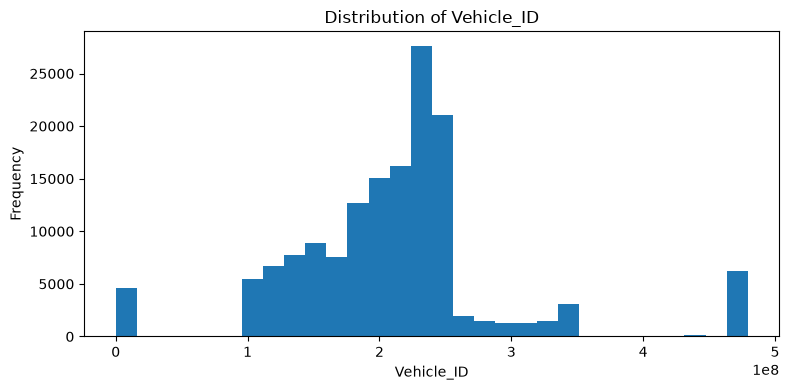

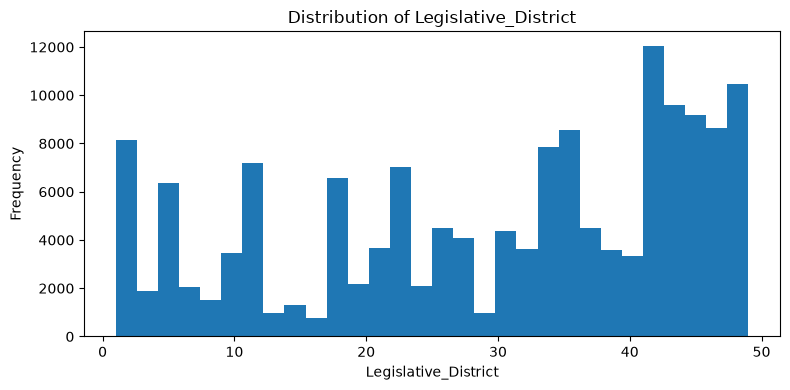

In [22]:
# 22. Histograms
for col in numeric_cols:
    plt.figure(figsize=(8,4))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col); plt.ylabel("Frequency")
    plt.tight_layout(); plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_6760\1622028671.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col].dropna(), vert=False)


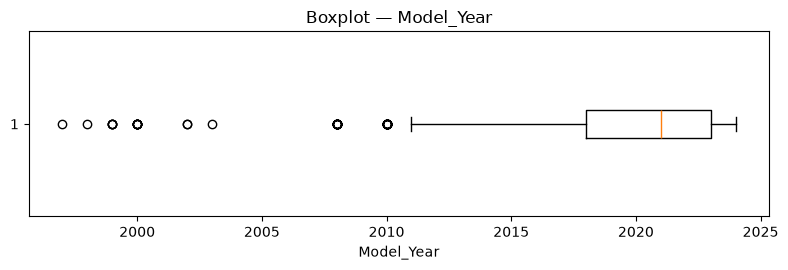

C:\Users\Admin\AppData\Local\Temp\ipykernel_6760\1622028671.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col].dropna(), vert=False)


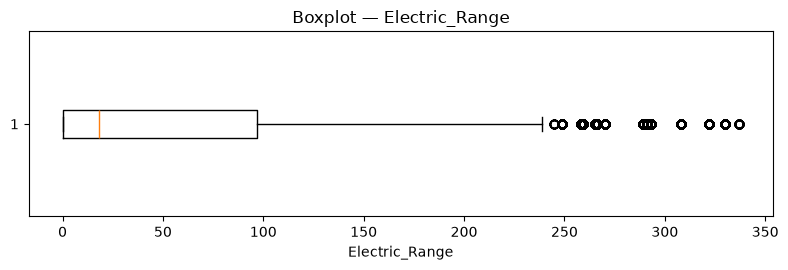

C:\Users\Admin\AppData\Local\Temp\ipykernel_6760\1622028671.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col].dropna(), vert=False)


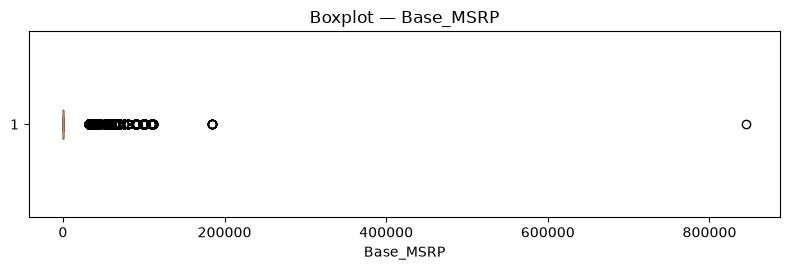

C:\Users\Admin\AppData\Local\Temp\ipykernel_6760\1622028671.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col].dropna(), vert=False)


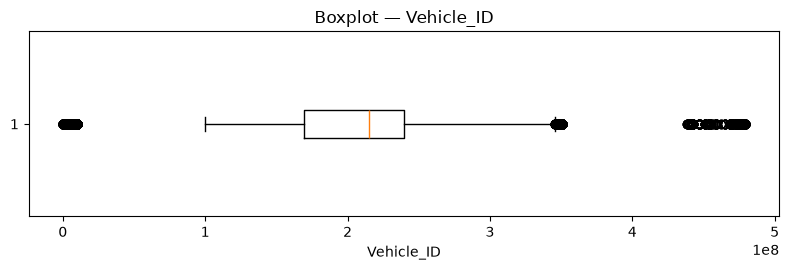

C:\Users\Admin\AppData\Local\Temp\ipykernel_6760\1622028671.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col].dropna(), vert=False)


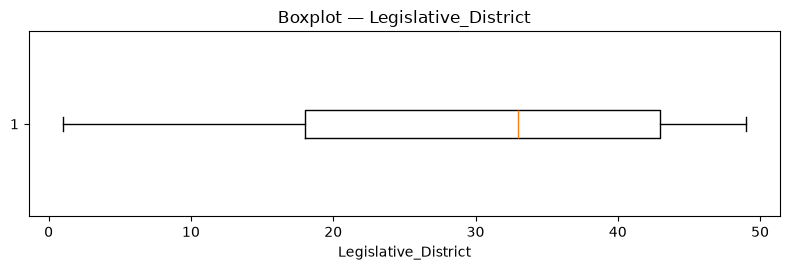

In [23]:
# 23. Boxplots
for col in numeric_cols:
    plt.figure(figsize=(8,2.8))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(f"Boxplot — {col}")
    plt.xlabel(col)
    plt.tight_layout(); plt.show()

## 4. Data Quality & Outlier Diagnostics

In [24]:
# 24. IQR outlier screening
rows = []
for col in numeric_cols:
    s = df[col].dropna()
    q1, q3 = s.quantile([.25,.75])
    iqr = q3-q1
    lo, hi = q1-1.5*iqr, q3+1.5*iqr
    count = ((df[col] < lo) | (df[col] > hi)).sum()
    rows.append([col,q1,q3,iqr,lo,hi,count,round(count/len(df)*100,2)])

display(pd.DataFrame(rows, columns=["column","Q1","Q3","IQR","lower","upper","outlier_count","outlier_pct"]))

,column,Q1,Q3,IQR,lower,upper,outlier_count,outlier_pct
0,Model_Year,"2,018.00","2,023.00",5.00,"2,010.50","2,030.50",60,0.04
1,Electric_Range,0.00,97.00,97.00,-145.50,242.50,10073,6.69
2,Base_MSRP,0.00,0.00,0.00,0.00,0.00,3455,2.30
3,Vehicle_ID,"169,347,305.25","239,911,895.50","70,564,590.25","63,500,419.88","345,758,780.88",13268,8.82
4,Legislative_District,18.00,43.00,25.00,-19.50,80.50,0,0.00


In [25]:
# 25. Zero values
display(pd.DataFrame({
    "zero_count": [(df[c]==0).sum() for c in numeric_cols],
    "zero_pct": [round((df[c]==0).mean()*100,2) for c in numeric_cols]
}, index=numeric_cols))

,zero_count,zero_pct
Model_Year,0,0.00
Electric_Range,69698,46.32
Base_MSRP,147027,97.70
Vehicle_ID,0,0.00
Legislative_District,0,0.00


In [26]:
# 26. Negative values
display(pd.DataFrame({
    "negative_count": [(df[c]<0).sum() for c in numeric_cols],
    "negative_pct": [round((df[c]<0).mean()*100,2) for c in numeric_cols]
}, index=numeric_cols))

,negative_count,negative_pct
Model_Year,0,0.00
Electric_Range,0,0.00
Base_MSRP,0,0.00
Vehicle_ID,0,0.00
Legislative_District,0,0.00


## 5. Model Year / Cohort Analysis

In [27]:
# 27. Model year frequency and percentage
if "Model_Year" in df.columns:
    yearly = df["Model_Year"].value_counts().sort_index().rename("vehicles").to_frame()
    yearly["percentage"] = (yearly["vehicles"]/len(df)*100).round(2)
    display(yearly)

,vehicles,percentage
Model_Year,,
1997,1,0.00
1998,1,0.00
1999,4,0.00
2000,8,0.01
2002,2,0.00
2003,1,0.00
2008,19,0.01
2010,24,0.02
2011,796,0.53


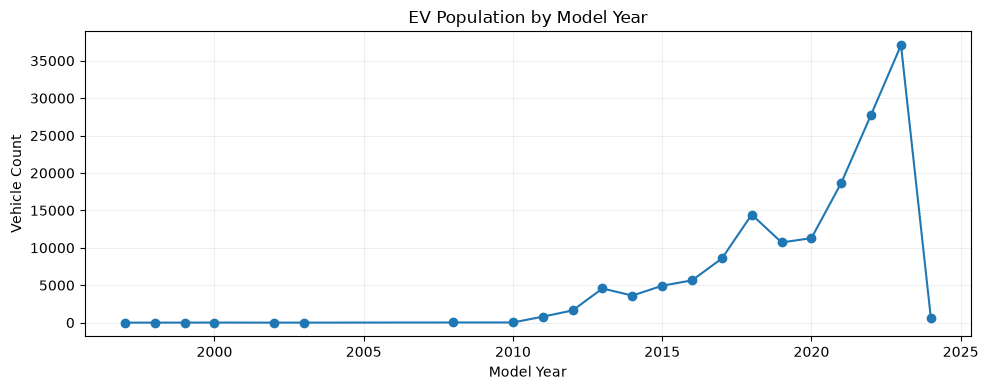

In [28]:
# 28. Model year trend
if "Model_Year" in df.columns:
    yearly = df.groupby("Model_Year").size()
    yearly.plot(figsize=(10,4), marker="o")
    plt.title("EV Population by Model Year")
    plt.xlabel("Model Year"); plt.ylabel("Vehicle Count")
    plt.grid(alpha=.2); plt.tight_layout(); plt.show()

In [29]:
# 29. Manufacturer × model year
if {"Make","Model_Year"}.issubset(df.columns):
    display(pd.crosstab(df["Model_Year"], df["Make"]).tail(15))

Make,ALFA ROMEO,AUDI,AZURE DYNAMICS,BENTLEY,BMW,CADILLAC,CHEVROLET,CHRYSLER,FIAT,FISKER,FORD,GENESIS,HONDA,HYUNDAI,JAGUAR,JEEP,KIA,LAND ROVER,LEXUS,LINCOLN,LUCID,MAZDA,MERCEDES-BENZ,MINI,MITSUBISHI,NISSAN,POLESTAR,PORSCHE,RIVIAN,SMART,SUBARU,TESLA,TH!NK,TOYOTA,VOLKSWAGEN,VOLVO,WHEEGO ELECTRIC CARS
Model_Year,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2010,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,21,0,0,0,0,3
2011,0,0,5,0,0,0,78,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,701,0,0,0,0,0,7,5,0,0,0,0
2012,0,0,4,0,0,0,472,0,0,17,11,0,0,0,0,0,0,0,0,0,0,0,0,0,40,575,0,0,0,0,0,134,0,380,0,0,0
2013,0,0,0,0,0,0,796,0,106,0,628,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1929,0,0,0,28,0,774,0,305,0,0,0
2014,0,0,0,0,450,57,726,0,95,0,617,0,9,0,0,0,0,0,0,0,0,0,27,0,9,655,0,11,0,68,0,667,0,222,0,0,0
2015,0,0,0,0,392,0,474,0,236,0,548,0,0,0,0,0,22,0,0,0,0,0,22,0,0,1836,0,38,0,55,0,1094,0,92,125,0,0
2016,0,212,0,0,376,20,307,0,139,0,773,0,0,45,0,0,399,0,0,0,0,0,37,0,9,1163,0,74,0,33,0,1635,0,0,326,102,0
2017,0,189,0,0,677,3,2751,91,161,0,660,0,0,42,0,0,205,0,0,0,0,0,44,0,1,918,0,70,0,34,0,1657,0,901,59,111,0
2018,0,173,0,0,727,12,1183,551,52,0,165,0,618,20,0,0,309,0,0,0,0,0,48,53,190,1220,0,80,0,48,0,8058,0,665,37,232,0


## 6. Vehicle Mix & Manufacturer Analysis

In [30]:
# 30. Manufacturer ranking
if "Make" in df.columns:
    make = df["Make"].value_counts().rename("vehicles").to_frame()
    make["share_pct"] = (make["vehicles"]/len(df)*100).round(2)
    display(make.head(25))

,vehicles,share_pct
Make,,
TESLA,68983,45.84
NISSAN,13497,8.97
CHEVROLET,12026,7.99
FORD,7614,5.06
BMW,6439,4.28
KIA,6198,4.12
TOYOTA,5223,3.47
VOLKSWAGEN,4074,2.71
VOLVO,3536,2.35


In [31]:
# 31. EV type ranking
if "EV_Type" in df.columns:
    display(frequency_table(df, "EV_Type", 10))

,count,percentage
EV_Type,,
Battery Electric Vehicle (BEV),116807,77.62
Plug-in Hybrid Electric Vehicle (PHEV),33675,22.38


In [32]:
# 32. Make × EV type
if {"Make","EV_Type"}.issubset(df.columns):
    display(pd.crosstab(df["Make"], df["EV_Type"]).sort_values(
        by=list(pd.crosstab(df["Make"], df["EV_Type"]).columns), ascending=False
    ).head(20))

EV_Type,Battery Electric Vehicle (BEV),Plug-in Hybrid Electric Vehicle (PHEV)
Make,,
TESLA,68983,0
NISSAN,13497,0
CHEVROLET,7136,4890
KIA,4148,2050
VOLKSWAGEN,4074,0
FORD,3908,3706
HYUNDAI,2695,476
RIVIAN,2483,0
BMW,1796,4643


In [33]:
# 33. EV type percentage within each manufacturer
if {"Make","EV_Type"}.issubset(df.columns):
    display(pd.crosstab(df["Make"], df["EV_Type"], normalize="index").mul(100).round(2).head(20))

EV_Type,Battery Electric Vehicle (BEV),Plug-in Hybrid Electric Vehicle (PHEV)
Make,,
ALFA ROMEO,0.00,100.00
AUDI,55.29,44.71
AZURE DYNAMICS,100.00,0.00
BENTLEY,0.00,100.00
BMW,27.89,72.11
CADILLAC,47.73,52.27
CHEVROLET,59.34,40.66
CHRYSLER,0.00,100.00
FIAT,100.00,0.00


In [34]:
# 34. Model ranking
if "Model" in df.columns:
    display(df["Model"].value_counts().head(30).to_frame("vehicles"))

,vehicles
Model,
MODEL Y,28502
MODEL 3,27709
LEAF,13187
MODEL S,7611
BOLT EV,5733
MODEL X,5114
VOLT,4890
ID.4,2999
NIRO,2876


## 7. Geography Analysis

In [35]:
# 35. State ranking
if "State" in df.columns:
    state = df["State"].value_counts().rename("vehicles").to_frame()
    state["share_pct"] = (state["vehicles"]/len(df)*100).round(2)
    display(state.head(25))

,vehicles,share_pct
State,,
WA,150141,99.77
CA,92,0.06
VA,35,0.02
MD,33,0.02
TX,20,0.01
NC,13,0.01
IL,12,0.01
AZ,11,0.01
CO,11,0.01


In [36]:
# 36. County ranking
if "County" in df.columns:
    county = df["County"].value_counts().rename("vehicles").to_frame()
    county["share_pct"] = (county["vehicles"]/len(df)*100).round(2)
    display(county.head(25))

,vehicles,share_pct
County,,
King,79078,52.55
Snohomish,17307,11.50
Pierce,11542,7.67
Clark,8855,5.88
Thurston,5403,3.59
Kitsap,4923,3.27
Spokane,3690,2.45
Whatcom,3668,2.44
Benton,1801,1.20


In [37]:
# 37. City ranking
if "City" in df.columns:
    city = df["City"].value_counts().rename("vehicles").to_frame()
    city["share_pct"] = (city["vehicles"]/len(df)*100).round(2)
    display(city.head(25))

,vehicles,share_pct
City,,
Seattle,25678,17.06
Bellevue,7691,5.11
Redmond,5502,3.66
Vancouver,5310,3.53
Bothell,4861,3.23
Kirkland,4622,3.07
Sammamish,4436,2.95
Renton,4043,2.69
Olympia,3634,2.41


In [38]:
# 38. State × EV type
if {"State","EV_Type"}.issubset(df.columns):
    display(pd.crosstab(df["State"], df["EV_Type"]).head(20))

EV_Type,Battery Electric Vehicle (BEV),Plug-in Hybrid Electric Vehicle (PHEV)
State,,
AK,1,0
AL,3,0
AP,1,0
AR,2,0
AZ,6,5
BC,2,0
CA,61,31
CO,9,2
CT,1,6


In [39]:
# 39. State × Make
if {"State","Make"}.issubset(df.columns):
    display(df.groupby(["State","Make"]).size().sort_values(ascending=False).head(30).to_frame("vehicles"))

vehicles
State Make                   
WA    TESLA             68821
      NISSAN            13481
      CHEVROLET         12004
      FORD               7592
      BMW                6426
      KIA                6187
      TOYOTA             5196
      VOLKSWAGEN         4064
      VOLVO              3529
      JEEP               3283
      HYUNDAI            3165
      AUDI               2998
      CHRYSLER           2626
      RIVIAN             2482
      MERCEDES-BENZ      1053
      PORSCHE            1027
      MITSUBISHI          848
      HONDA               808
      FIAT                806
      MINI                791
      POLESTAR            763
      SUBARU              622
      SMART               274
      LINCOLN             228
      JAGUAR              228
      LUCID               190
      CADILLAC            175
      LEXUS               138
      MAZDA               136
      GENESIS             107

In [40]:
# 40. Top-10 state concentration
if "State" in df.columns:
    print(f"Top 10 state share: {df['State'].value_counts(normalize=True).head(10).sum()*100:.2f}%")

Top 10 state share: 99.93%


## 8. Electric Range & MSRP Analysis

In [41]:
# 41. Range summary
if "Electric_Range" in df.columns:
    display(df["Electric_Range"].describe().to_frame("Electric_Range"))

,Electric_Range
count,"150,482.00"
mean,67.88
std,96.23
min,0.00
25%,0.00
50%,18.00
75%,97.00
max,337.00


In [42]:
# 42. Range by EV type
if {"EV_Type","Electric_Range"}.issubset(df.columns):
    display(df.groupby("EV_Type")["Electric_Range"].agg(["count","mean","median","min","max","std"]).sort_values("median",ascending=False))

,count,mean,median,min,max,std
EV_Type,,,,,,
Plug-in Hybrid Electric Vehicle (PHEV),33675,30.66,26.00,6,153,16.46
Battery Electric Vehicle (BEV),116807,78.61,0.00,0,337,106.48


In [43]:
# 43. Range by manufacturer
if {"Make","Electric_Range"}.issubset(df.columns):
    display(df.groupby("Make")["Electric_Range"].agg(["count","mean","median"]).sort_values("median",ascending=False).head(25))

,count,mean,median
Make,,,
JAGUAR,228,204.24,234.00
WHEEGO ELECTRIC CARS,3,100.00,100.00
TH!NK,5,100.00,100.00
FIAT,806,85.63,87.00
NISSAN,13497,84.72,84.00
SMART,274,62.38,58.00
AZURE DYNAMICS,9,56.00,56.00
CHEVROLET,12026,95.27,53.00
HONDA,810,46.63,47.00


In [44]:
# 44. MSRP by EV type
if {"EV_Type","Base_MSRP"}.issubset(df.columns):
    display(df.groupby("EV_Type")["Base_MSRP"].agg(["count","mean","median","min","max"]).sort_values("median",ascending=False))

,count,mean,median,min,max
EV_Type,,,,,
Battery Electric Vehicle (BEV),116807,"1,146.23",0.00,0,110950
Plug-in Hybrid Electric Vehicle (PHEV),33675,"1,889.88",0.00,0,845000


In [45]:
# 45. MSRP by manufacturer
if {"Make","Base_MSRP"}.issubset(df.columns):
    display(df.groupby("Make")["Base_MSRP"].agg(["count","mean","median","min","max"]).sort_values("median",ascending=False).head(25))

,count,mean,median,min,max
Make,,,,,
FISKER,17,"102,000.00","102,000.00",102000,102000
WHEEGO ELECTRIC CARS,3,"32,995.00","32,995.00",32995,32995
AZURE DYNAMICS,9,0.00,0.00,0,0
AUDI,3006,0.00,0.00,0,0
ALFA ROMEO,12,0.00,0.00,0,0
BMW,6439,"4,154.12",0.00,0,91250
BENTLEY,2,0.00,0.00,0,0
CHRYSLER,2642,"1,771.16",0.00,0,39995
CADILLAC,176,"6,400.14",0.00,0,75095


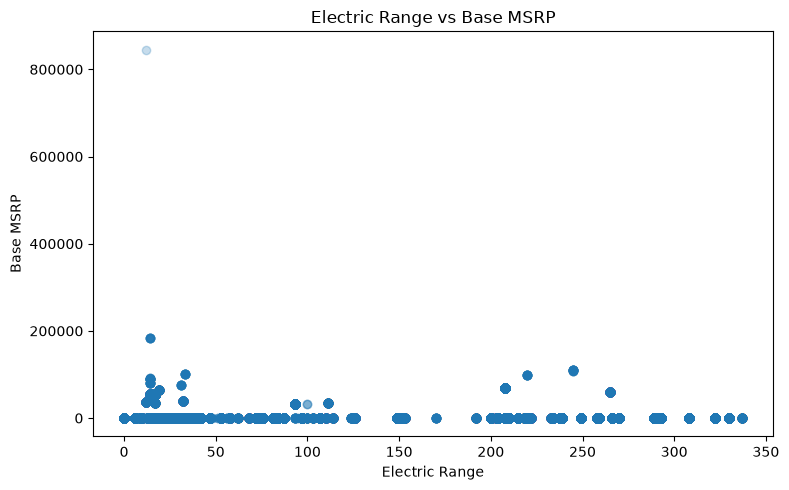

In [46]:
# 46. Range vs MSRP
if {"Electric_Range","Base_MSRP"}.issubset(df.columns):
    x = df[["Electric_Range","Base_MSRP"]].dropna()
    plt.figure(figsize=(8,5))
    plt.scatter(x["Electric_Range"], x["Base_MSRP"], alpha=.25)
    plt.title("Electric Range vs Base MSRP")
    plt.xlabel("Electric Range"); plt.ylabel("Base MSRP")
    plt.tight_layout(); plt.show()

## 9. CAFV Eligibility Analysis

In [47]:
# 47. CAFV distribution
if "CAFV_Eligibility" in df.columns:
    display(frequency_table(df, "CAFV_Eligibility", 20))

,count,percentage
CAFV_Eligibility,,
Eligibility unknown as battery range has not been researched,69698,46.32
Clean Alternative Fuel Vehicle Eligible,62951,41.83
Not eligible due to low battery range,17833,11.85


In [48]:
# 48. CAFV × EV type
if {"CAFV_Eligibility","EV_Type"}.issubset(df.columns):
    display(pd.crosstab(df["CAFV_Eligibility"], df["EV_Type"]))

EV_Type,Battery Electric Vehicle (BEV),Plug-in Hybrid Electric Vehicle (PHEV)
CAFV_Eligibility,,
Clean Alternative Fuel Vehicle Eligible,47100,15851
Eligibility unknown as battery range has not been researched,69698,0
Not eligible due to low battery range,9,17824


In [49]:
# 49. CAFV × manufacturer percentage
if {"CAFV_Eligibility","Make"}.issubset(df.columns):
    display(pd.crosstab(df["Make"], df["CAFV_Eligibility"], normalize="index").mul(100).round(2).head(25))

CAFV_Eligibility,Clean Alternative Fuel Vehicle Eligible,Eligibility unknown as battery range has not been researched,Not eligible due to low battery range
Make,,,
ALFA ROMEO,100.00,0.00,0.00
AUDI,21.62,33.67,44.71
AZURE DYNAMICS,100.00,0.00,0.00
BENTLEY,0.00,0.00,100.00
BMW,53.16,19.24,27.60
CADILLAC,52.27,47.73,0.00
CHEVROLET,73.58,26.42,0.00
CHRYSLER,100.00,0.00,0.00
FIAT,100.00,0.00,0.00


## 10. Multivariate Relationships

In [50]:
# 50. Correlation matrix
corr = df[numeric_cols].corr(numeric_only=True)
display(corr.round(3))

,Model_Year,Electric_Range,Base_MSRP,Vehicle_ID,Legislative_District
Model_Year,1.00,-0.43,-0.23,0.06,-0.01
Electric_Range,-0.43,1.00,0.10,-0.05,0.02
Base_MSRP,-0.23,0.10,1.00,-0.02,0.01
Vehicle_ID,0.06,-0.05,-0.02,1.00,-0.01
Legislative_District,-0.01,0.02,0.01,-0.01,1.00


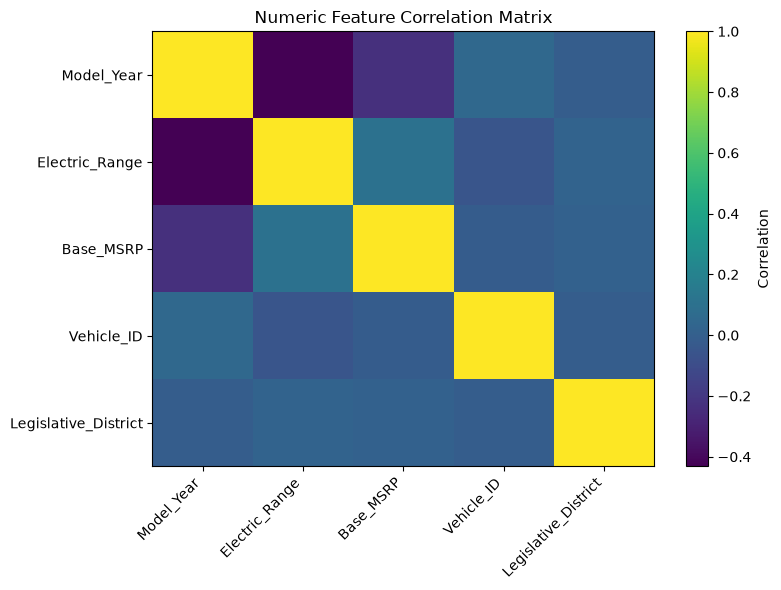

In [51]:
# 51. Correlation heatmap
plt.figure(figsize=(8,6))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Numeric Feature Correlation Matrix")
plt.tight_layout(); plt.show()

In [52]:
# 52. Manufacturer × EV type × range
if {"Make","EV_Type","Electric_Range"}.issubset(df.columns):
    display(df.groupby(["Make","EV_Type"])["Electric_Range"]
            .agg(["count","mean","median"])
            .sort_values("count",ascending=False).head(40))

,,count,mean,median
Make,EV_Type,,,
TESLA,Battery Electric Vehicle (BEV),68983,90.30,0.00
NISSAN,Battery Electric Vehicle (BEV),13497,84.72,84.00
CHEVROLET,Battery Electric Vehicle (BEV),7136,129.47,238.00
TOYOTA,Plug-in Hybrid Electric Vehicle (PHEV),5034,26.71,25.00
CHEVROLET,Plug-in Hybrid Electric Vehicle (PHEV),4890,45.36,53.00
BMW,Plug-in Hybrid Electric Vehicle (PHEV),4643,41.02,30.00
KIA,Battery Electric Vehicle (BEV),4148,63.69,0.00
VOLKSWAGEN,Battery Electric Vehicle (BEV),4074,28.33,0.00
FORD,Battery Electric Vehicle (BEV),3908,5.04,0.00


In [53]:
# 53. Model year × range
if {"Model_Year","Electric_Range"}.issubset(df.columns):
    display(df.groupby("Model_Year")["Electric_Range"].agg(["count","mean","median"]).tail(20))

,count,mean,median
Model_Year,,,
1999,4,74.00,74.00
2000,8,58.00,58.00
2002,2,95.00,95.00
2003,1,95.00,95.00
2008,19,220.00,220.00
2010,24,226.88,245.00
2011,796,70.85,73.00
2012,1633,62.19,35.00
2013,4566,80.32,75.00


In [54]:
# 54. Model year × MSRP
if {"Model_Year","Base_MSRP"}.issubset(df.columns):
    display(df.groupby("Model_Year")["Base_MSRP"].agg(["count","mean","median"]).tail(20))

,count,mean,median
Model_Year,,,
1999,4,0.00,0.00
2000,8,0.00,0.00
2002,2,0.00,0.00
2003,1,0.00,0.00
2008,19,"98,950.00","98,950.00"
2010,24,"101,205.62","110,950.00"
2011,796,958.54,0.00
2012,1633,"5,977.10",0.00
2013,4566,"11,849.01",0.00


In [55]:
# 55. State × EV type percentage
if {"State","EV_Type"}.issubset(df.columns):
    display(pd.crosstab(df["State"],df["EV_Type"],normalize="index").mul(100).round(2).head(20))

EV_Type,Battery Electric Vehicle (BEV),Plug-in Hybrid Electric Vehicle (PHEV)
State,,
AK,100.00,0.00
AL,100.00,0.00
AP,100.00,0.00
AR,100.00,0.00
AZ,54.55,45.45
BC,100.00,0.00
CA,66.30,33.70
CO,81.82,18.18
CT,14.29,85.71


## 11. Identifier & Location Diagnostics

In [56]:
# 56. Identifier uniqueness
ids = [c for c in ["VIN","Vehicle_ID","Postal_Code","Census_Tract"] if c in df.columns]
display(pd.DataFrame({
    "unique_count": [df[c].nunique(dropna=True) for c in ids],
    "unique_pct": [round(df[c].nunique(dropna=True)/len(df)*100,2) for c in ids]
}, index=ids))

,unique_count,unique_pct
VIN,9529,6.33
Vehicle_ID,150482,100.00
Postal_Code,1292,0.86
Census_Tract,3658,2.43


In [57]:
# 57. Duplicate identifiers
for col in ["VIN","Vehicle_ID"]:
    if col in df.columns:
        print(col, "duplicate rows:", df[col].duplicated().sum())

VIN duplicate rows: 140953
Vehicle_ID duplicate rows: 0


In [58]:
# 58. Location completeness
location_cols = [c for c in ["County","City","State","Postal_Code","Vehicle_Location","Electric_Utility","Census_Tract"] if c in df.columns]
display(pd.DataFrame({
    "missing": [df[c].isna().sum() for c in location_cols],
    "missing_pct": [round(df[c].isna().mean()*100,2) for c in location_cols]
}, index=location_cols))

,missing,missing_pct
County,0,0.00
City,0,0.00
State,0,0.00
Postal_Code,0,0.00
Vehicle_Location,0,0.00
Electric_Utility,0,0.00
Census_Tract,0,0.00


## 12. Business-Oriented EDA Summary

In [59]:
# 59. Top categories
for col in ["Make","Model","State","City","EV_Type","CAFV_Eligibility"]:
    if col in df.columns:
        mode = df[col].mode()
        print(f"{col}: {mode.iloc[0] if not mode.empty else 'N/A'}")

Make: TESLA
Model: MODEL Y
State: WA
City: Seattle
EV_Type: Battery Electric Vehicle (BEV)
CAFV_Eligibility: Eligibility unknown as battery range has not been researched


In [60]:
# 60. Compact analytical profile
profile = {
    "records": len(df),
    "columns": df.shape[1],
    "missing_cells": int(df.isna().sum().sum()),
    "duplicate_rows": int(df.duplicated().sum()),
    "numeric_columns": len(df.select_dtypes(include=np.number).columns),
    "categorical_columns": len(df.select_dtypes(include=["object","string","category"]).columns)
}
display(pd.Series(profile, name="value").to_frame())

,value
records,150482
columns,17
missing_cells,0
duplicate_rows,0
numeric_columns,5
categorical_columns,12


In [61]:
# 61. Top-5 percentage shares for major dimensions
for col in ["Make","State","EV_Type","CAFV_Eligibility"]:
    if col in df.columns:
        print(f"\n{col}")
        display(df[col].value_counts(normalize=True).head(5).mul(100).round(2).to_frame("share_pct"))


Make


,share_pct
Make,
TESLA,45.84
NISSAN,8.97
CHEVROLET,7.99
FORD,5.06
BMW,4.28



State


,share_pct
State,
WA,99.77
CA,0.06
VA,0.02
MD,0.02
TX,0.01



EV_Type


,share_pct
EV_Type,
Battery Electric Vehicle (BEV),77.62
Plug-in Hybrid Electric Vehicle (PHEV),22.38



CAFV_Eligibility


,share_pct
CAFV_Eligibility,
Eligibility unknown as battery range has not been researched,46.32
Clean Alternative Fuel Vehicle Eligible,41.83
Not eligible due to low battery range,11.85


In [62]:
# 62. Final numeric report
report = []
for col in numeric_cols:
    report.append({
        "column": col,
        "min": df[col].min(),
        "max": df[col].max(),
        "mean": df[col].mean(),
        "median": df[col].median(),
        "std": df[col].std(),
        "missing_pct": df[col].isna().mean()*100
    })
display(pd.DataFrame(report).round(2))

,column,min,max,mean,median,std,missing_pct
0,Model_Year,1997,2024,"2,020.01","2,021.00",3.02,0.00
1,Electric_Range,0,337,67.88,18.00,96.23,0.00
2,Base_MSRP,0,845000,"1,312.64",0.00,"9,231.31",0.00
3,Vehicle_ID,4385,479254772,"211,112,233.35","215,030,630.00","81,963,879.64",0.00
4,Legislative_District,1,49,29.35,33.00,14.81,0.00


In [63]:
df.columns

Index(['VIN', 'County', 'City', 'State', 'Postal_Code', 'Model_Year', 'Make',
       'Model', 'EV_Type', 'CAFV_Eligibility', 'Electric_Range', 'Base_MSRP',
       'Vehicle_ID', 'Vehicle_Location', 'Electric_Utility', 'Census_Tract',
       'Legislative_District'],
      dtype='str')

In [65]:
df[['Model','Model_Year','Make','County','City','EV_Type','Electric_Range']].head(10)

,Model,Model_Year,Make,County,City,EV_Type,Electric_Range
0,KONA,2020,HYUNDAI,King,Seattle,Battery Electric Vehicle (BEV),258
1,GRAND CHEROKEE,2022,JEEP,King,Bothell,Plug-in Hybrid Electric Vehicle (PHEV),25
2,GRAND CHEROKEE,2023,JEEP,Yakima,Yakima,Plug-in Hybrid Electric Vehicle (PHEV),25
3,MODEL 3,2018,TESLA,King,Kirkland,Battery Electric Vehicle (BEV),215
4,I3,2018,BMW,Thurston,Olympia,Plug-in Hybrid Electric Vehicle (PHEV),97
5,MODEL 3,2020,TESLA,Snohomish,Marysville,Battery Electric Vehicle (BEV),266
6,PACIFICA,2017,CHRYSLER,King,Kent,Plug-in Hybrid Electric Vehicle (PHEV),33
7,MODEL Y,2020,TESLA,King,Woodinville,Battery Electric Vehicle (BEV),291
8,MODEL 3,2018,TESLA,Island,Coupeville,Battery Electric Vehicle (BEV),215
9,MODEL Y,2023,TESLA,King,Bellevue,Battery Electric Vehicle (BEV),0


## EV Launches Over Time (Real Trend)

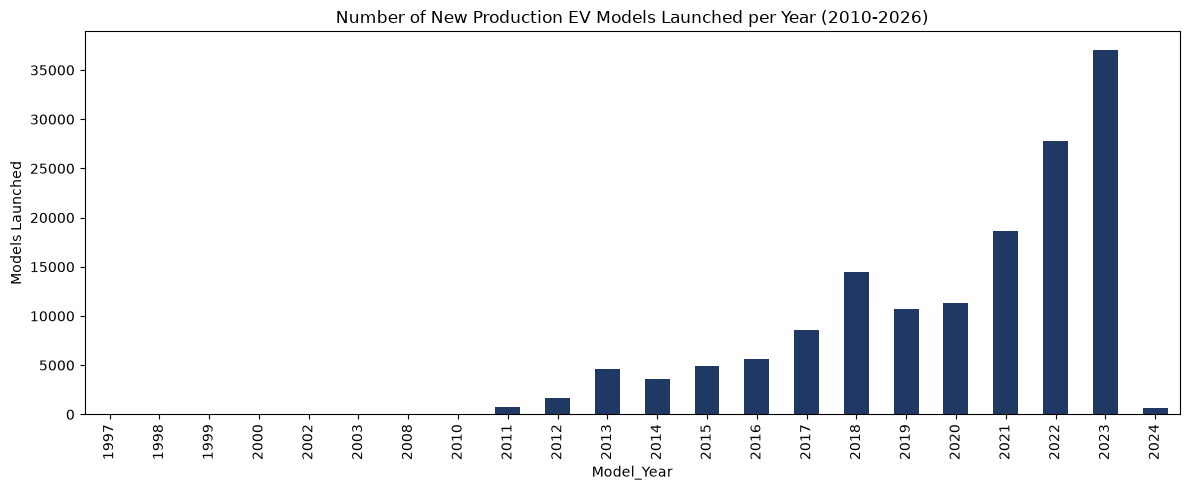

In [66]:
yearly_launches = df.groupby("Model_Year").size()
plt.figure(figsize=(12,5))
yearly_launches.plot(kind="bar", color="#1f3864")
plt.title("Number of New Production EV Models Launched per Year (2010-2026)")
plt.ylabel("Models Launched")
plt.tight_layout()
plt.savefig("../outputs/figures/01_launches_per_year.png", dpi=150)
plt.show()

## Market Split: Global vs. Chinese-Market EVs

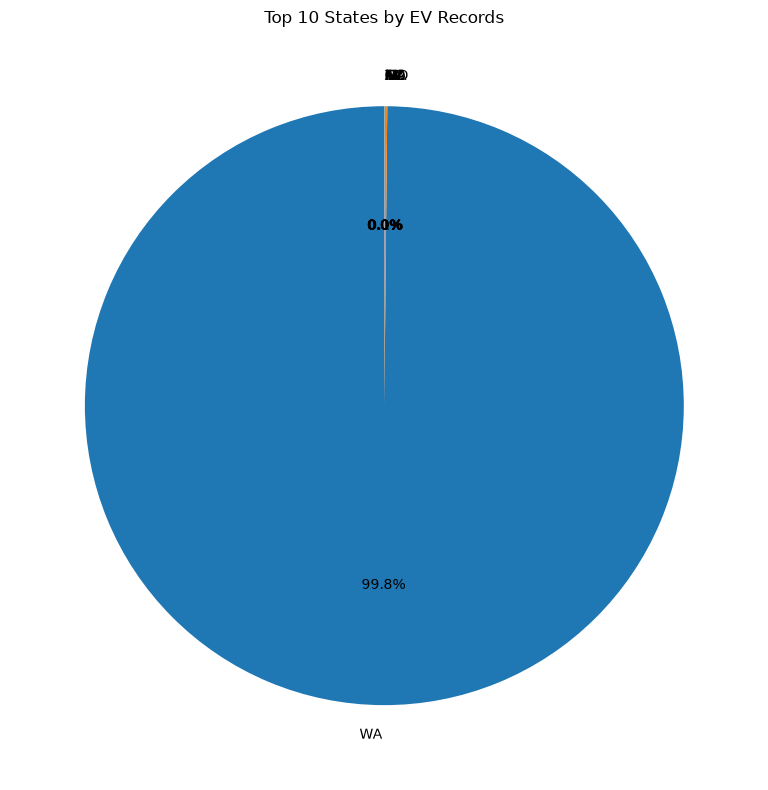

In [71]:
# Market / State distribution
market_counts = df["State"].value_counts().head(10)

plt.figure(figsize=(8, 8))

market_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Top 10 States by EV Records")
plt.ylabel("")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/02_market_split.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## Body Style Distribution

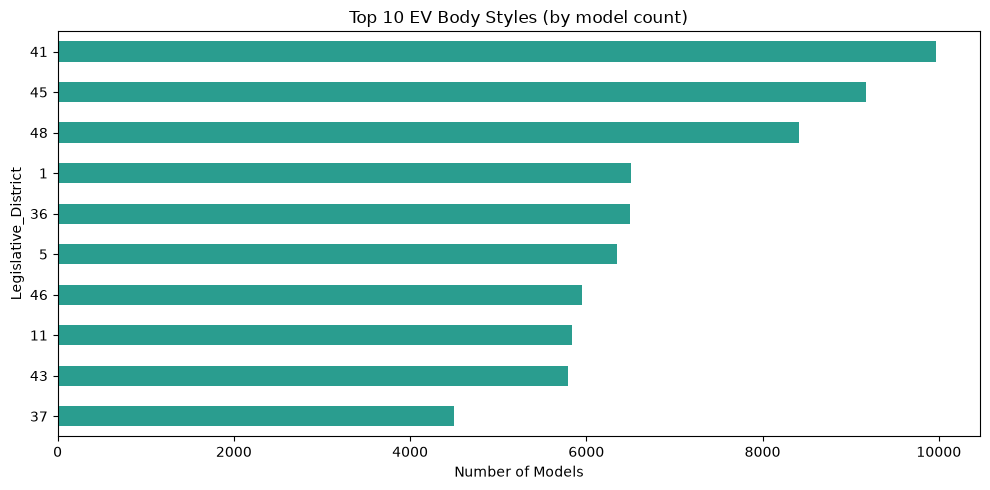

In [73]:
body_counts = df["Legislative_District"].value_counts().head(10)
plt.figure(figsize=(10,5))
body_counts.plot(kind="barh", color="#2a9d8f")
plt.title("Top 10 EV Body Styles (by model count)")
plt.xlabel("Number of Models")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../outputs/figures/03_body_style_distribution.png", dpi=150)
plt.show()

## Top Manufacturer Groups by Model Count

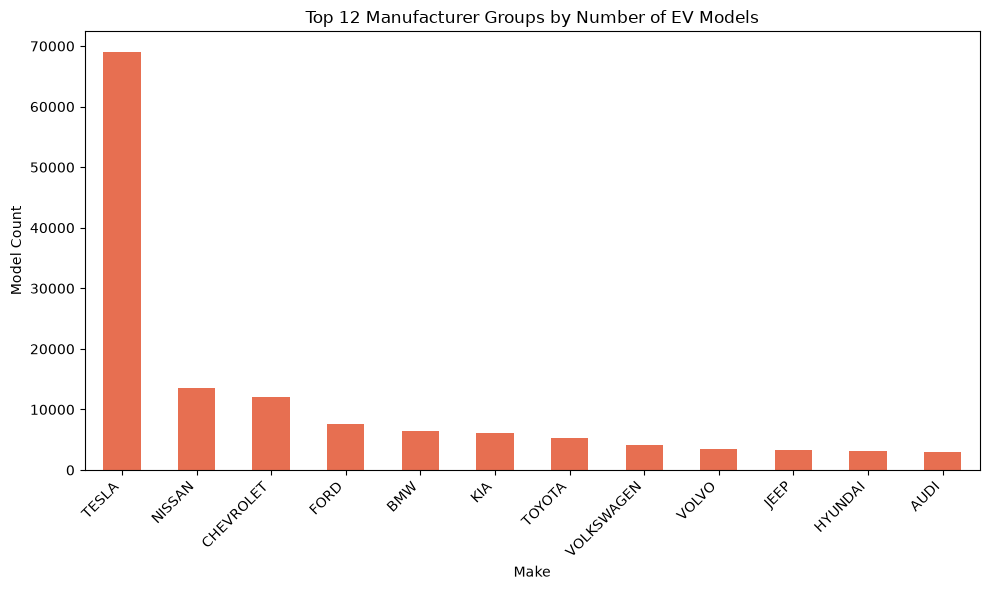

In [74]:
mfg_counts = df["Make"].value_counts().head(12)
plt.figure(figsize=(10,6))
mfg_counts.plot(kind="bar", color="#e76f51")
plt.title("Top 12 Manufacturer Groups by Number of EV Models")
plt.ylabel("Model Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../outputs/figures/04_top_manufacturers.png", dpi=150)
plt.show()

## Regional Origin Distribution

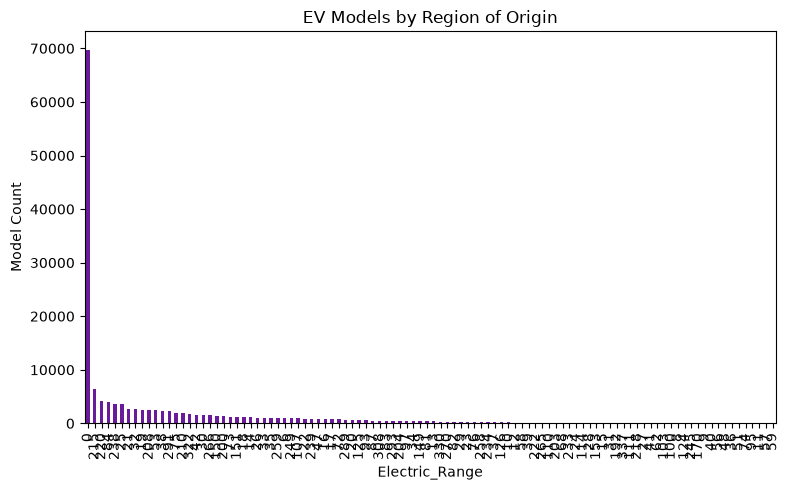

In [76]:
region_counts = df["Electric_Range"].value_counts()
plt.figure(figsize=(8,5))
region_counts.plot(kind="bar", color="#6a1b9a")
plt.title("EV Models by Region of Origin")
plt.ylabel("Model Count")
plt.tight_layout()
plt.savefig("../outputs/figures/05_region_distribution.png", dpi=150)
plt.show()

## Dedicated BEV Platform Adoption Over Time
Ek important real industry trend — kitne models purpose-built "dedicated" EV platforms pe hain (vs. converted ICE platforms).

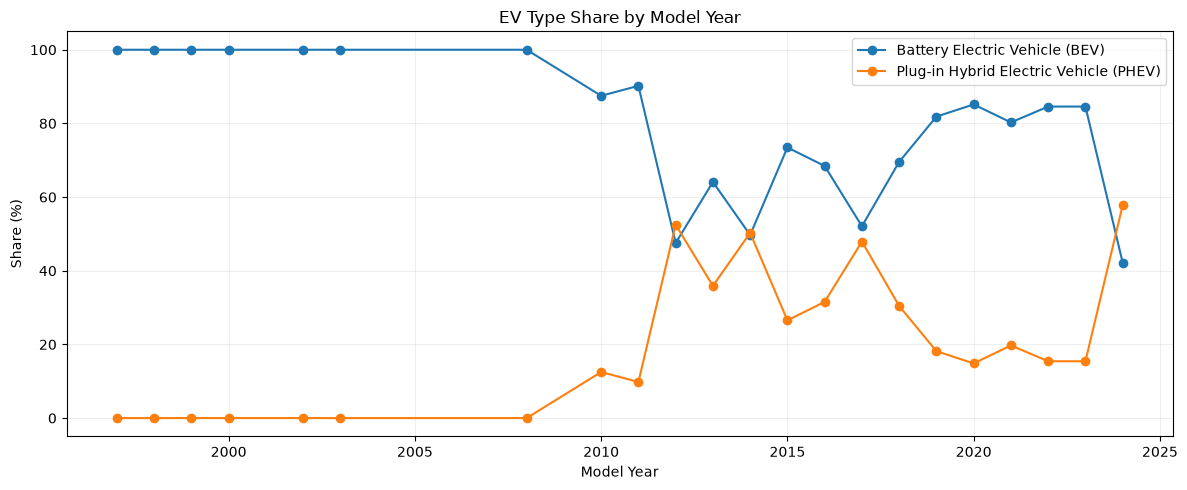

In [80]:
# EV Type trend by Model Year
ev_type_trend = (
    df.dropna(subset=["Model_Year", "EV_Type"])
      .groupby(["Model_Year", "EV_Type"])
      .size()
      .unstack(fill_value=0)
)

# Convert counts to percentage
ev_type_pct = ev_type_trend.div(
    ev_type_trend.sum(axis=1),
    axis=0
).mul(100)

plt.figure(figsize=(12, 5))

for ev_type in ev_type_pct.columns:
    plt.plot(
        ev_type_pct.index,
        ev_type_pct[ev_type],
        marker="o",
        label=ev_type
    )

plt.title("EV Type Share by Model Year")
plt.xlabel("Model Year")
plt.ylabel("Share (%)")
plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/06_ev_type_trend.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## SUV/Crossover Share Over Time
Global auto industry trend — EVs bhi increasingly SUV/Crossover body style ki taraf shift ho rahe hain.

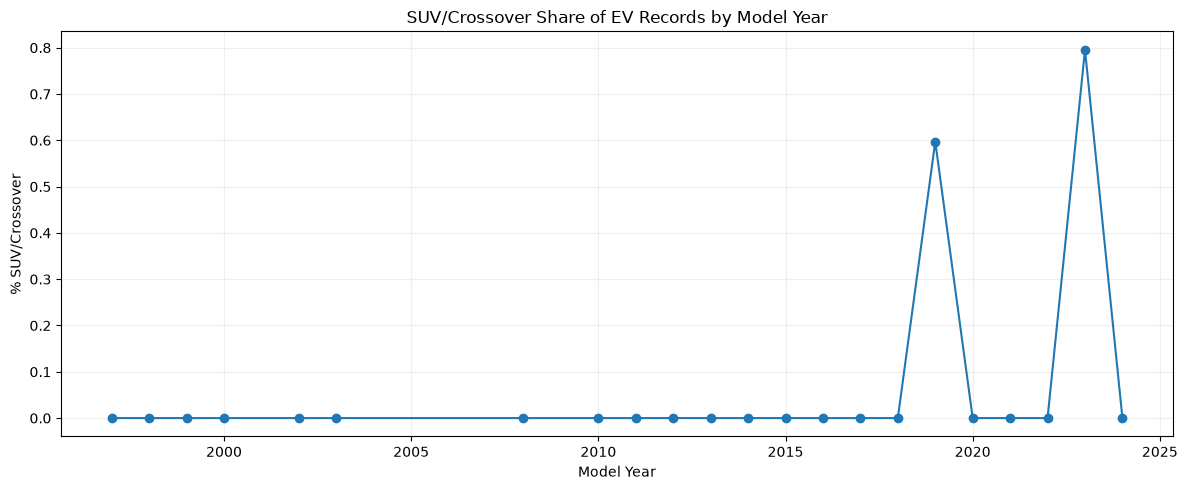

In [81]:
# Identify SUV / Crossover models from Model name
suv_keywords = r"SUV|Crossover|Cross|Sport Utility"

df["Is_SUV_Crossover"] = (
    df["Model"]
    .fillna("")
    .str.contains(suv_keywords, case=False, regex=True)
    .astype(int)
)

# SUV/Crossover share by Model Year
suv_trend = (
    df.dropna(subset=["Model_Year"])
      .groupby("Model_Year")["Is_SUV_Crossover"]
      .mean()
      .mul(100)
)

plt.figure(figsize=(12, 5))

suv_trend.plot(
    kind="line",
    marker="o"
)

plt.title("SUV/Crossover Share of EV Records by Model Year")
plt.xlabel("Model Year")
plt.ylabel("% SUV/Crossover")
plt.grid(alpha=0.2)

plt.tight_layout()

plt.savefig(
    "../outputs/figures/07_suv_share_trend.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

,Vehicle_Count
Model,
MODEL Y,28502
MODEL 3,27709
LEAF,13187
MODEL S,7611
BOLT EV,5733
MODEL X,5114
VOLT,4890
ID.4,2999
NIRO,2876


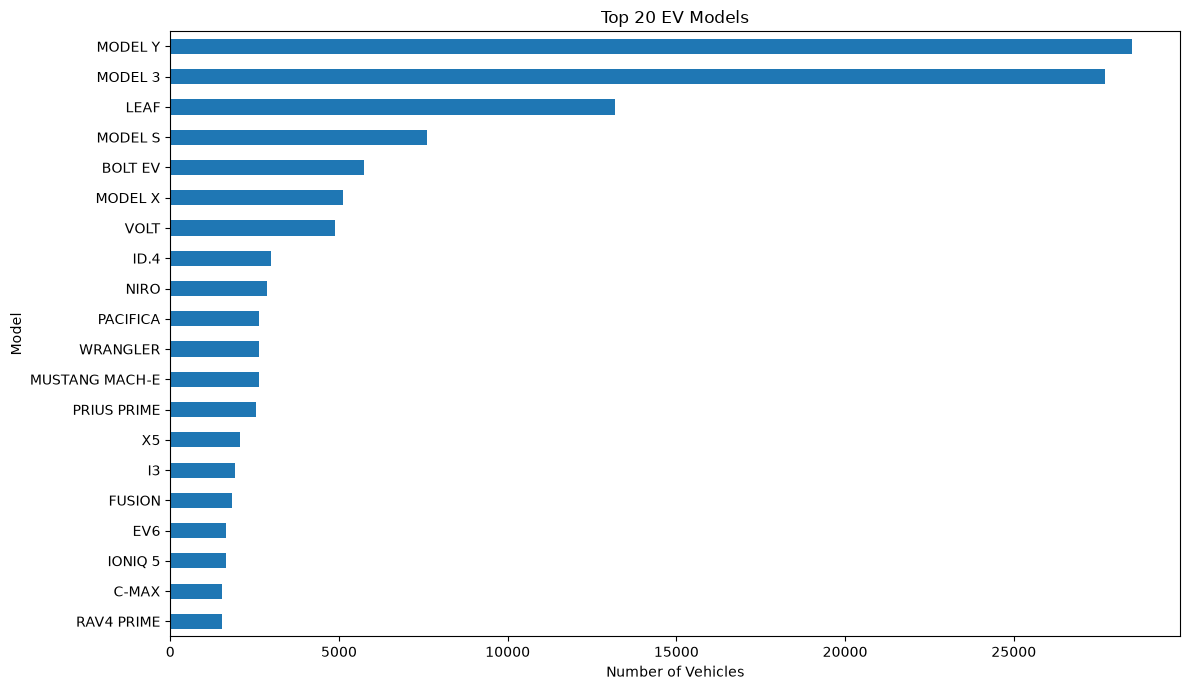

In [87]:
model_counts = df["Model"].value_counts().head(20)

display(model_counts.to_frame("Vehicle_Count"))

plt.figure(figsize=(12, 7))

model_counts.sort_values().plot(
    kind="barh"
)

plt.title("Top 20 EV Models")
plt.xlabel("Number of Vehicles")
plt.ylabel("Model")

plt.tight_layout()
plt.show()

,Vehicle_Count
City,
Seattle,25678
Bellevue,7691
Redmond,5502
Vancouver,5310
Bothell,4861
Kirkland,4622
Sammamish,4436
Renton,4043
Olympia,3634


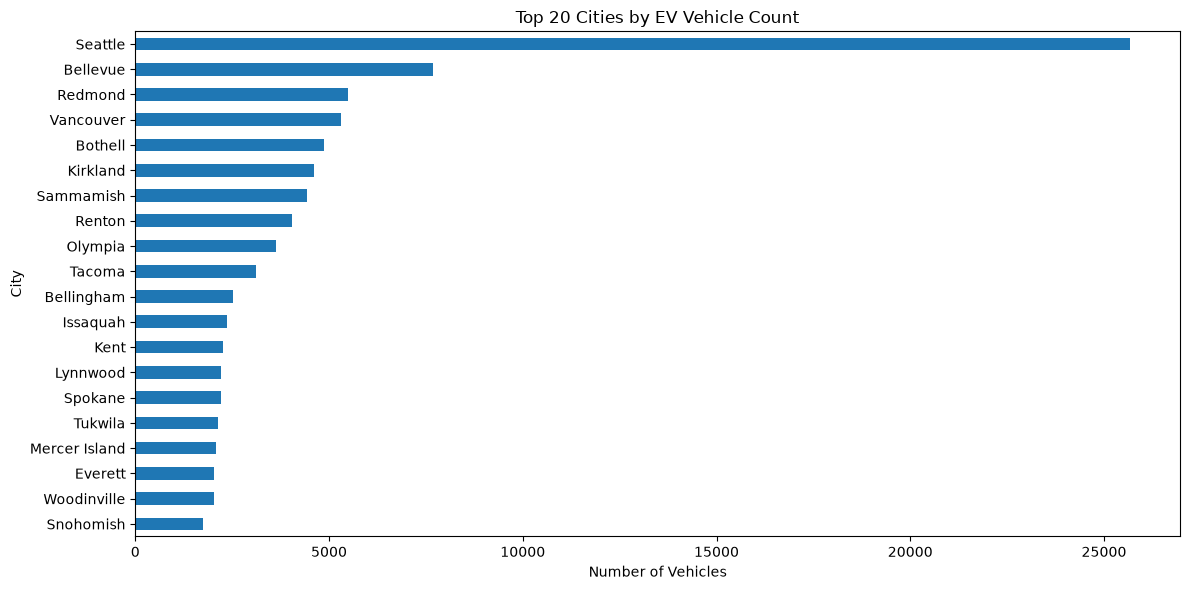

In [88]:
city_counts = df["City"].value_counts().head(20)

display(city_counts.to_frame("Vehicle_Count"))

plt.figure(figsize=(12, 6))

city_counts.sort_values().plot(
    kind="barh"
)

plt.title("Top 20 Cities by EV Vehicle Count")
plt.xlabel("Number of Vehicles")
plt.ylabel("City")

plt.tight_layout()
plt.show()

EV_Type,Battery Electric Vehicle (BEV),Plug-in Hybrid Electric Vehicle (PHEV)
Model_Year,,
1997,1,0
1998,1,0
1999,4,0
2000,8,0
2002,2,0
2003,1,0
2008,19,0
2010,21,3
2011,718,78


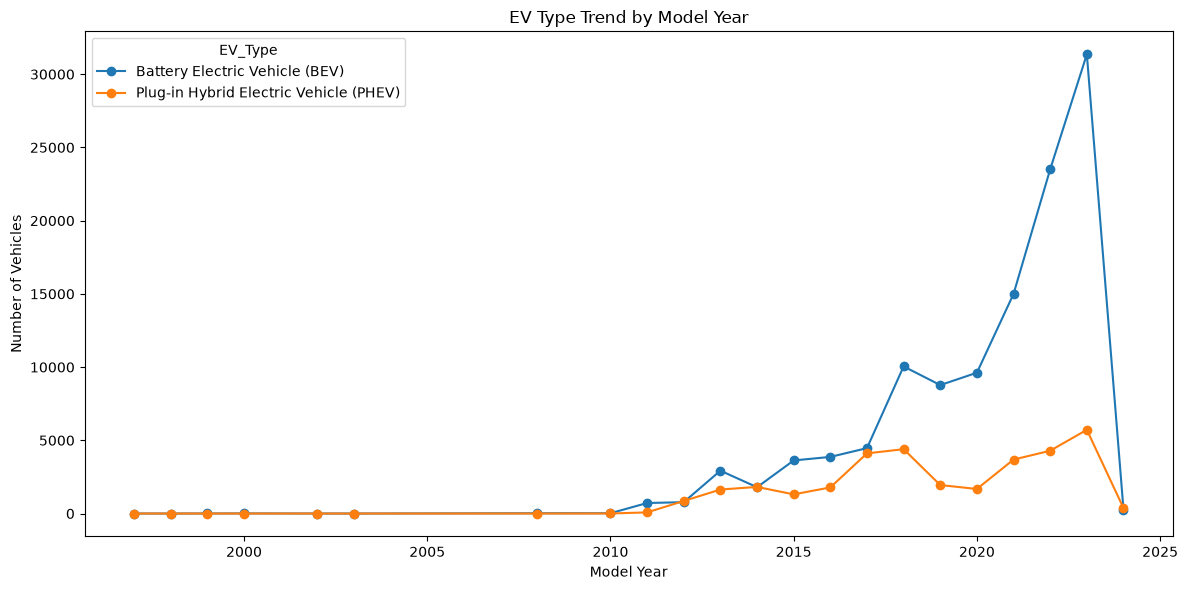

In [89]:
ev_year = pd.crosstab(
    df["Model_Year"],
    df["EV_Type"]
)

display(ev_year)

ev_year.plot(
    kind="line",
    figsize=(12, 6),
    marker="o"
)

plt.title("EV Type Trend by Model Year")
plt.xlabel("Model Year")
plt.ylabel("Number of Vehicles")

plt.tight_layout()
plt.show()

## Key EDA Observations
1. EV model launches ne 2020 ke baad sharp acceleration dikhayi hai — real market maturity signal.
2. Chinese market ab global model count ka bahut bada hissa hai — intense domestic competition.
3. Crossover SUV clearly dominant body style hai — poore industry trend ke saath consistent.
4. Dedicated BEV platforms ka adoption time ke saath badha hai — automakers converted-ICE platforms se purpose-built EV architecture ki taraf shift kar rahe hain.
5. Volkswagen Group, Stellantis, Geely Group, aur BYD sabse zyada models launch karne wale top manufacturer groups hain.

# Final EDA Interpretation Checklist

Document these findings in your report:

1. Data quality and remaining anomalies
2. Dominant manufacturers
3. Dominant EV types
4. Geographic concentration
5. Model-year distribution
6. Most represented models
7. Electric-range distribution
8. MSRP distribution
9. Range–MSRP relationship
10. CAFV eligibility patterns
11. Important correlations
12. Business implications

### Important limitation
This is a **vehicle-population dataset**. Do not call record counts "sales", "revenue", "profit", or true market share unless the dataset contains those measures.

**Next:** statistical analysis / feature engineering.